In [30]:
'''
# 📦 Schritt 1: Bibliotheken importieren
import pandas as pd
import glob
import os

# 📁 Schritt 2: Pfad zu den Metrics-Dateien definieren
folder_path = "/Users/niklas/Desktop/Diplomarbeit/OptRail_Railroad_Construction/Data/Solution_PSA_DbSA_400/"
file_pattern = os.path.join(folder_path, "Metrics_*.csv")

# 📂 Schritt 3: Alle passenden CSV-Dateien finden
file_list = glob.glob(file_pattern)
print(f"{len(file_list)} Dateien gefunden.")
for file in file_list:
    print(f"Gefundene Datei: {file}")

# 📊 Schritt 4: Alle Dateien einlesen und zusammenfügen
all_dfs = [pd.read_csv(file) for file in file_list]
full_df = pd.concat(all_dfs, ignore_index=True)
print("Daten erfolgreich zusammengeführt.")
display(full_df.head())

# 📈 Schritt 5: Durchschnittswerte pro Instanz + Algorithmus berechnen
average_df = full_df.groupby(["Instance", "Algorithm"], as_index=False).mean()
print("Durchschnittswerte berechnet.")
display(average_df.head())

# 💾 Schritt 6: Ergebnis abspeichern
output_path = os.path.join(folder_path, "Metrics_averaged.csv")
average_df.to_csv(output_path, index=False)
print(f"Aggregierte Datei gespeichert unter: {output_path}")
'''

'\n# 📦 Schritt 1: Bibliotheken importieren\nimport pandas as pd\nimport glob\nimport os\n\n# 📁 Schritt 2: Pfad zu den Metrics-Dateien definieren\nfolder_path = "/Users/niklas/Desktop/Diplomarbeit/OptRail_Railroad_Construction/Data/Solution_PSA_DbSA_400/"\nfile_pattern = os.path.join(folder_path, "Metrics_*.csv")\n\n# 📂 Schritt 3: Alle passenden CSV-Dateien finden\nfile_list = glob.glob(file_pattern)\nprint(f"{len(file_list)} Dateien gefunden.")\nfor file in file_list:\n    print(f"Gefundene Datei: {file}")\n\n# 📊 Schritt 4: Alle Dateien einlesen und zusammenfügen\nall_dfs = [pd.read_csv(file) for file in file_list]\nfull_df = pd.concat(all_dfs, ignore_index=True)\nprint("Daten erfolgreich zusammengeführt.")\ndisplay(full_df.head())\n\n# 📈 Schritt 5: Durchschnittswerte pro Instanz + Algorithmus berechnen\naverage_df = full_df.groupby(["Instance", "Algorithm"], as_index=False).mean()\nprint("Durchschnittswerte berechnet.")\ndisplay(average_df.head())\n\n# 💾 Schritt 6: Ergebnis abspeicher

In [31]:
import pandas as pd

# Datei einlesen (Pfad ggf. anpassen, falls Datei woanders liegt)
df = pd.read_csv("Metrics_averaged.csv")

# Rundung zur besseren Lesbarkeit (optional)
df_rounded = df.round(3)

# Ausgabe als DataFrame mit schöner Formatierung
from IPython.display import display, HTML
display(HTML(df_rounded.to_html(index=False)))

Instance,Algorithm,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
a10_o107_m5_an57_ar12,DbSA,172.190,0.695,0.195,0.347,0.269,31.929,0.033,0.497
a10_o107_m5_an57_ar12,PSA,186.192,0.389,1.096,0.261,0.265,9.513,0.070,0.424
a10_o107_m5_an57_ar12,TPSA,182.380,0.887,0.178,0.370,0.118,58.558,0.044,0.702
a10_o114_m6_an57_ar11,DbSA,318.292,0.830,0.183,0.381,0.126,51.214,0.059,0.757
a10_o114_m6_an57_ar11,PSA,321.585,0.409,1.025,0.367,0.164,11.062,0.129,0.729
a10_o114_m6_an57_ar11,TPSA,327.875,0.664,0.142,0.342,0.215,37.724,0.066,0.980
a10_o128_m6_an51_ar13,DbSA,250.665,0.812,0.243,0.005,0.236,55.632,0.049,0.809
a10_o128_m6_an51_ar13,PSA,219.440,0.273,0.892,0.005,0.207,7.708,0.135,0.822
a10_o128_m6_an51_ar13,TPSA,270.885,0.715,0.172,0.005,0.198,36.660,0.043,0.970
a10_o144_m6_an53_ar12,DbSA,172.420,0.604,0.289,0.485,0.243,32.532,0.058,0.508


In [32]:
# Durchschnittswerte je Algorithmus
df.groupby("Algorithm").mean(numeric_only=True).round(3)

,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
Algorithm,,,,,,,,
DbSA,634.725,0.748,0.189,0.166,0.267,40.533,0.039,0.585
PSA,680.929,0.501,0.488,0.154,0.235,15.174,0.069,0.628
TPSA,595.371,0.797,0.130,0.178,0.141,44.293,0.047,0.854


In [33]:
# Standardabweichungen je Algorithmus
df.groupby("Algorithm").std(numeric_only=True).round(3)

,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
Algorithm,,,,,,,,
DbSA,576.890,0.086,0.076,0.198,0.081,8.344,0.017,0.130
PSA,633.274,0.143,0.373,0.175,0.071,5.650,0.041,0.127
TPSA,462.121,0.079,0.056,0.210,0.041,6.745,0.018,0.134


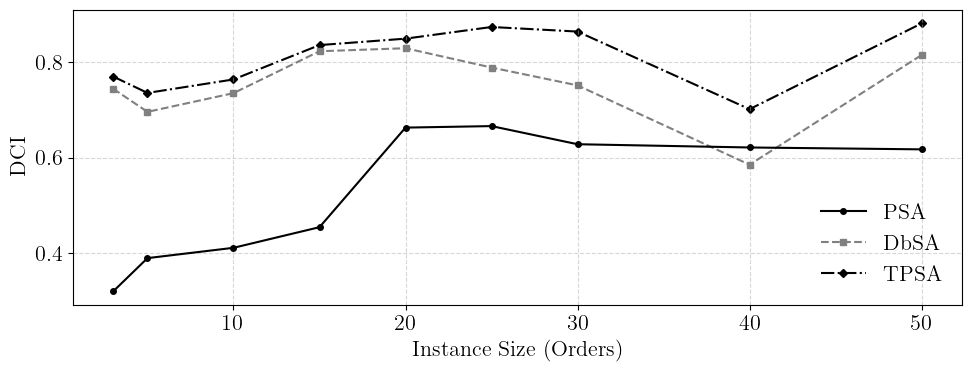

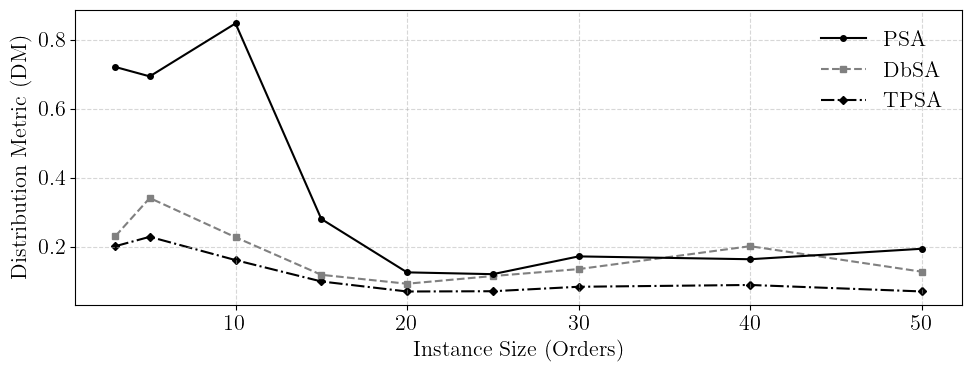

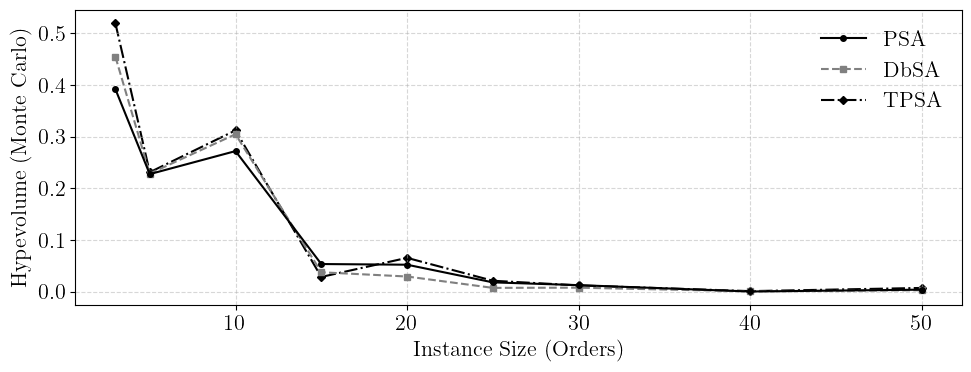

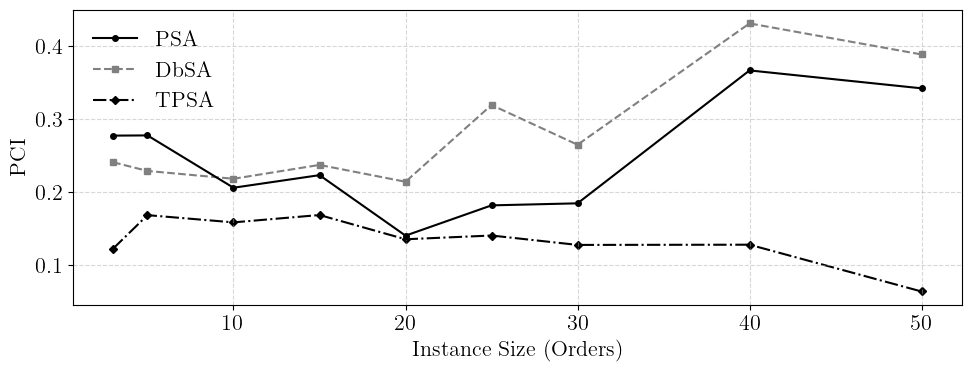

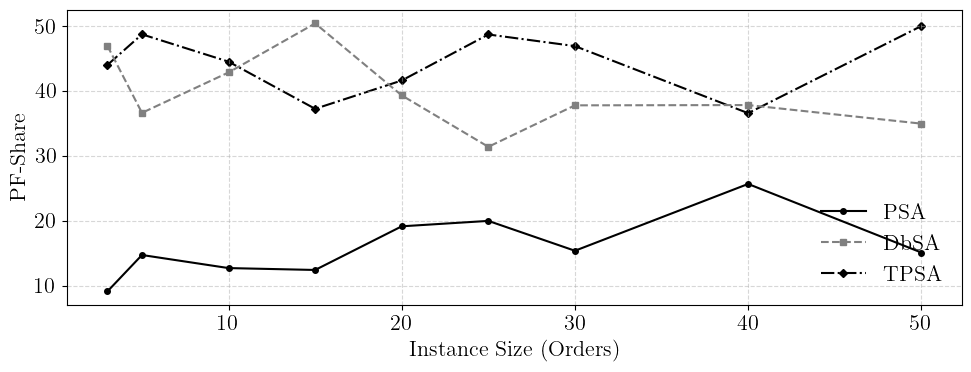

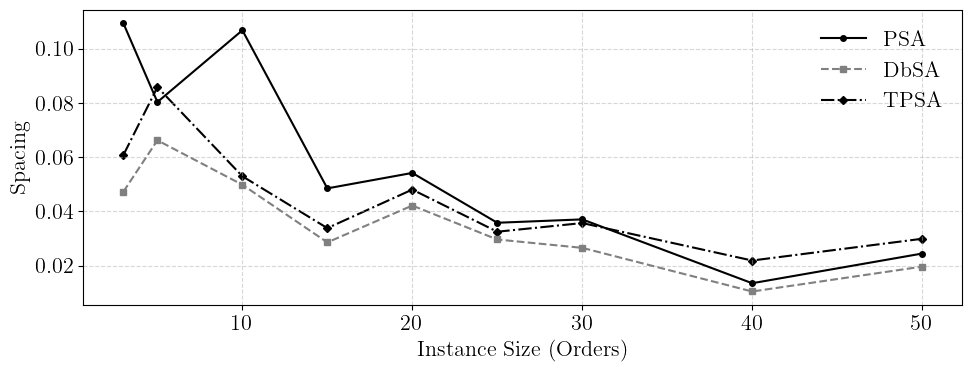

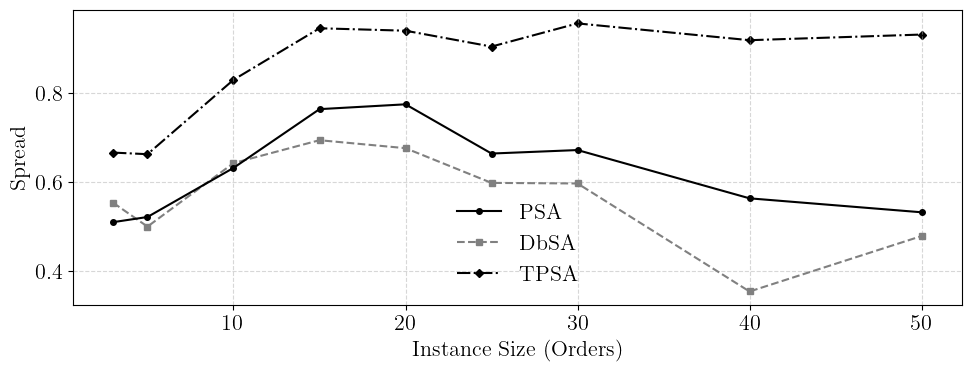

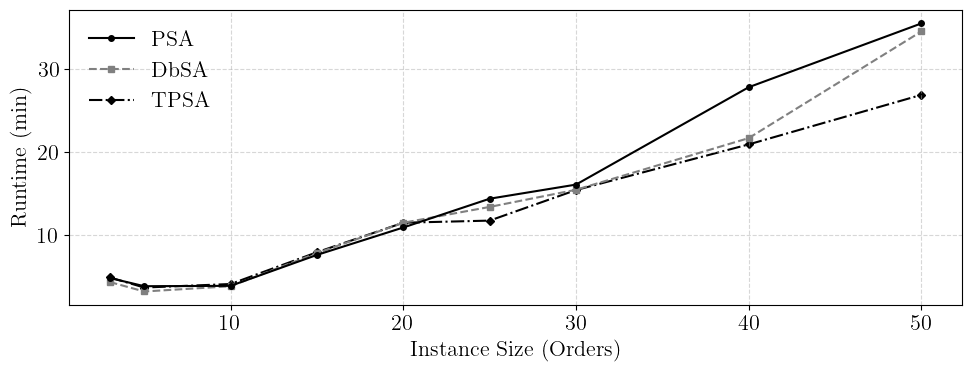

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 🎨 LaTeX-Stil global aktivieren
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "figure.titlesize": 16
})

# 📂 CSV einlesen
df = pd.read_csv("Metrics_averaged.csv")

# ⏱️ Wenn "Improvement Time" vorhanden ist, umbenennen und in Minuten umrechnen
if "Improvement_Time" in df.columns:
    df["Runtime (min)"] = df["Improvement_Time"] / 60
    df.drop(columns=["Improvement_Time"], inplace=True)

# 📊 Instanzgröße extrahieren
df["Instance_Size"] = df["Instance"].str.extract(r"a(\d+)_").astype(int)

# 🔎 Alle Metriken außer diesen:
metrics = [col for col in df.columns if col not in ["Instance", "Algorithm", "Instance_Size"]]

# 🧮 Durchschnitt berechnen
agg_df = df.groupby(["Instance_Size", "Algorithm"], as_index=False)[metrics].mean()
agg_df = agg_df.sort_values("Instance_Size")

# 🎨 Farb-/Stilzuordnung
style_map = {
    "PSA": {"label": "PSA", "linestyle": "-", "color": "black", "marker": "o", "zorder": 3},
    "DbSA": {"label": "DbSA", "linestyle": "--", "color": "gray", "marker": "s", "zorder": 2},
    "TPSA": {"label": "TPSA", "linestyle": "-.", "color": "black", "marker": "D", "zorder": 1},
}

# 📊 Plot für jede Metrik
for metric in metrics:
    plt.figure(figsize=(10, 4))

    for algo, style in style_map.items():
        subset = agg_df[agg_df["Algorithm"] == algo]
        plt.plot(
            subset["Instance_Size"], subset[metric],
            label=style["label"],
            linestyle=style["linestyle"],
            marker=style["marker"],
            color=style["color"],
            markersize=4,
            linewidth=1.5,
            zorder=style["zorder"]
        )

    # 📏 Formatierung
    #plt.title(metric)
    plt.xlabel("Instance Size (Orders)")
    plt.ylabel(metric)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(loc="best", frameon=False)
    plt.tight_layout()

    # Optional: Speichern als PDF
    #plt.savefig(f"{metric.replace(' ', '_').lower()}_lineplot.pdf", dpi=300, bbox_inches="tight")

    plt.show()

<Figure size 600x400 with 0 Axes>

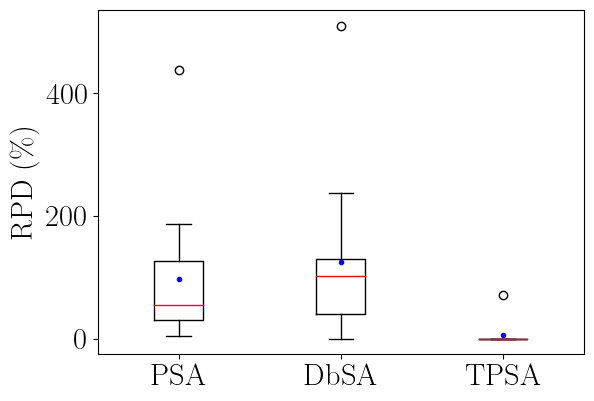


RPD-Werte für PCI – Algorithmus: PSA (absteigend sortiert):
                    Instance    PCI RPD
     a50_o578_m28_an276_ar66 437.237246
     a40_o476_m22_an215_ar51 186.861831
 a3_o80_m10_an10_ar9_reduced 126.561743
       a10_o107_m5_an57_ar12 125.467696
       a10_o144_m6_an53_ar12  82.172146
a5_o96_m10_an10_ar10_reduced  64.909060
     a30_o355_m18_an148_ar42  44.697947
       a15_o170_m9_an80_ar18  32.427158
       a10_o114_m6_an57_ar11  30.126364
     a25_o306_m13_an127_ar31  29.422080
       a10_o128_m6_an51_ar13   4.568570
     a20_o236_m12_an106_ar24   3.673450
  Algorithmus: PSA
    Q1: 29.9503
    Q2 (Median): 54.8035
    Mean: 97.3438
    Q3: 125.7412
    IQR: 95.7909
    Minimum: 3.6735
    Maximum: 437.2372
    Whisker min: 3.6735
    Whisker max: 186.8618
    Theoretical max whisker length (1.5 * IQR): 143.6864

RPD-Werte für PCI – Algorithmus: DbSA (absteigend sortiert):
                    Instance    PCI RPD
     a50_o578_m28_an276_ar66 510.101129
     a40_o476_m2

<Figure size 600x400 with 0 Axes>

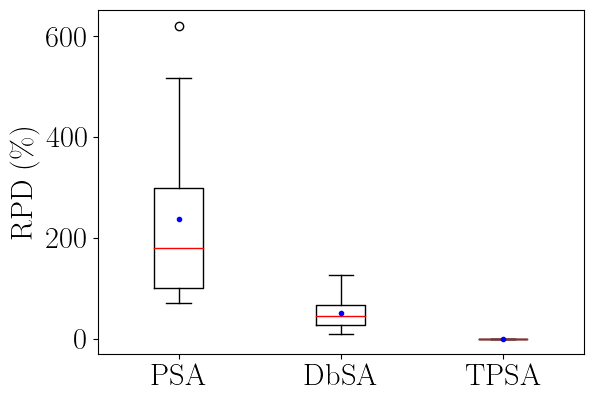


RPD-Werte für Distribution Metric (DM) – Algorithmus: PSA (absteigend sortiert):
                    Instance  Distribution Metric (DM) RPD
       a10_o114_m6_an57_ar11                    620.661625
       a10_o107_m5_an57_ar12                    516.374906
       a10_o128_m6_an51_ar13                    419.622353
 a3_o80_m10_an10_ar9_reduced                    257.472128
a5_o96_m10_an10_ar10_reduced                    203.223223
       a15_o170_m9_an80_ar18                    182.228092
     a50_o578_m28_an276_ar66                    175.485393
       a10_o144_m6_an53_ar12                    143.677348
     a30_o355_m18_an148_ar42                    104.730989
     a40_o476_m22_an215_ar51                     83.587650
     a20_o236_m12_an106_ar24                     78.889725
     a25_o306_m13_an127_ar31                     69.591676
  Algorithmus: PSA
    Q1: 99.4452
    Q2 (Median): 178.8567
    Mean: 237.9621
    Q3: 298.0097
    IQR: 198.5645
    Minimum: 69.5917
    Maximum: 62

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 📐 Stil: LaTeX-kompatible Darstellung für Publikationen
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 22,
    "axes.titlesize": 22,
    "axes.labelsize": 22,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 22,
    "figure.titlesize": 22
})

# 📂 CSV einlesen
df = pd.read_csv("Metrics_averaged.csv")

# 📊 Instanzgröße extrahieren (optional für spätere Analysen)
df["Instance_Size"] = df["Instance"].str.extract(r"a(\d+)_").astype(int)

# 🎯 Zielname
for objective in ["PCI", "Distribution Metric (DM)"]:
    # 🧮 RPD berechnen (Minimierungsproblem!)
    df["Best Value"] = df.groupby("Instance")[objective].transform("min")
    df[f"{objective} RPD"] = ((df[objective] - df["Best Value"]) / df["Best Value"]) * 100

    # 🧼 Methoden sortieren
    df["Algorithm"] = pd.Categorical(df["Algorithm"], categories=["PSA", "DbSA", "TPSA"], ordered=True)

    # 📦 Boxplot zeichnen
    plt.figure(figsize=(6, 4))
    df.boxplot(
        column=f"{objective} RPD",
        by="Algorithm",
        grid=False,
        showfliers=True,
        boxprops=dict(color="black"),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        medianprops=dict(color="red"),
        meanprops=dict(marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3),
        showmeans=True
    )

    # 🖼️ Achsen und Layout
    plt.title(f"RPD Distribution for {objective}", fontsize=12, pad=10)
    plt.title("")  
    plt.suptitle("")
    plt.xlabel("Method")
    plt.xlabel("")
    plt.ylabel("RPD (\%)")
    plt.tight_layout()

    # 💾 Optional: als PDF speichern
    #plt.savefig(f"rpd_boxplot_{objective.lower().replace(' ', '_')}.pdf", format="pdf", bbox_inches="tight", dpi=300)
    plt.show()
    # RPD-Werte je Algorithmus sortiert nach Größe ausgeben
    for alg in df["Algorithm"].cat.categories:
        rpd_col = f"{objective} RPD"
        rpd_sorted = df[df["Algorithm"] == alg][["Instance", rpd_col]].sort_values(by=rpd_col, ascending=False)
        print(f"\nRPD-Werte für {objective} – Algorithmus: {alg} (absteigend sortiert):")
        print(rpd_sorted.to_string(index=False))
        values = df[df["Algorithm"] == alg][rpd_col]
        q1 = values.quantile(0.25)
        q2 = values.quantile(0.5)
        q3 = values.quantile(0.75)
        iqr = q3 - q1
        mean = values.mean()
        whisker_min = values[values >= (q1 - 1.5 * iqr)].min()
        whisker_max = values[values <= (q3 + 1.5 * iqr)].max()
        minimum = values.min()
        maximum = values.max()
        print(f"  Algorithmus: {alg}")
        print(f"    Q1: {q1:.4f}")
        print(f"    Q2 (Median): {q2:.4f}")
        print(f"    Mean: {mean:.4f}")
        print(f"    Q3: {q3:.4f}")
        print(f"    IQR: {iqr:.4f}")
        print(f"    Minimum: {minimum:.4f}")
        print(f"    Maximum: {maximum:.4f}")
        print(f"    Whisker min: {whisker_min:.4f}")
        print(f"    Whisker max: {whisker_max:.4f}")
        print(f"    Theoretical max whisker length (1.5 * IQR): {(1.5 * iqr):.4f}")


<Figure size 600x400 with 0 Axes>

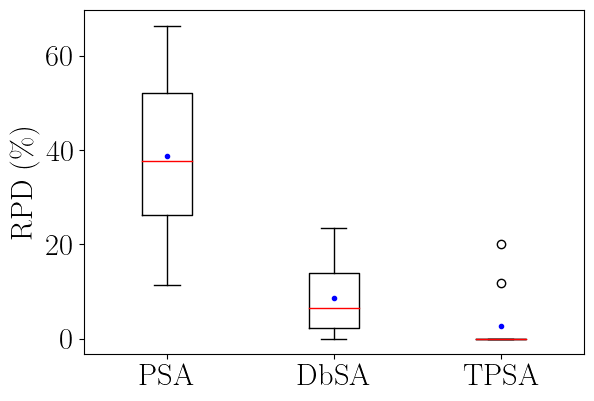


RPD-Werte für DCI – Algorithmus: PSA (absteigend sortiert):
                    Instance   DCI RPD
       a10_o128_m6_an51_ar13 66.381413
 a3_o80_m10_an10_ar9_reduced 58.429928
       a10_o107_m5_an57_ar12 56.166020
       a10_o114_m6_an57_ar11 50.723944
a5_o96_m10_an10_ar10_reduced 46.994316
       a15_o170_m9_an80_ar18 45.593870
     a50_o578_m28_an276_ar66 29.913842
     a30_o355_m18_an148_ar42 27.286029
       a10_o144_m6_an53_ar12 27.087224
     a25_o306_m13_an127_ar31 23.740121
     a20_o236_m12_an106_ar24 21.920533
     a40_o476_m22_an215_ar51 11.417839
  Algorithmus: PSA
    Q1: 26.2504
    Q2 (Median): 37.7539
    Mean: 38.8046
    Q3: 52.0845
    IQR: 25.8340
    Minimum: 11.4178
    Maximum: 66.3814
    Whisker min: 11.4178
    Whisker max: 66.3814
    Theoretical max whisker length (1.5 * IQR): 38.7510

RPD-Werte für DCI – Algorithmus: DbSA (absteigend sortiert):
                    Instance   DCI RPD
       a10_o144_m6_an53_ar12 23.407790
       a10_o107_m5_an57_ar12 21.7

<Figure size 600x400 with 0 Axes>

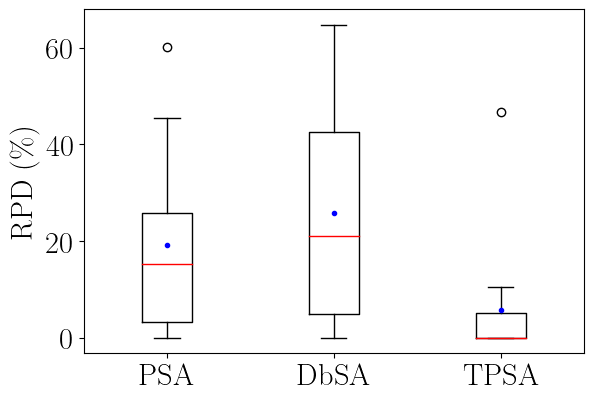


RPD-Werte für Hypevolume (Monte Carlo) – Algorithmus: PSA (absteigend sortiert):
                    Instance  Hypevolume (Monte Carlo) RPD
     a40_o476_m22_an215_ar51                     60.088692
     a50_o578_m28_an276_ar66                     45.342067
       a10_o107_m5_an57_ar12                     29.384051
 a3_o80_m10_an10_ar9_reduced                     24.531477
     a20_o236_m12_an106_ar24                     20.234592
       a10_o128_m6_an51_ar13                     15.494343
     a25_o306_m13_an127_ar31                     14.785454
       a10_o144_m6_an53_ar12                     14.497881
       a10_o114_m6_an57_ar11                      3.661433
a5_o96_m10_an10_ar10_reduced                      1.561630
       a15_o170_m9_an80_ar18                      0.000000
     a30_o355_m18_an148_ar42                      0.000000
  Algorithmus: PSA
    Q1: 3.1365
    Q2 (Median): 15.1399
    Mean: 19.1318
    Q3: 25.7446
    IQR: 22.6081
    Minimum: 0.0000
    Maximum: 60.0887


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 📐 Stil: LaTeX-kompatible Darstellung für Publikationen
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 22,
    "axes.titlesize": 22,
    "axes.labelsize": 22,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 22,
    "figure.titlesize": 22
})

# 📂 CSV einlesen
df = pd.read_csv("Metrics_averaged.csv")

# 📊 Instanzgröße extrahieren (optional für spätere Analysen)
df["Instance_Size"] = df["Instance"].str.extract(r"a(\d+)_").astype(int)

# 🎯 Zielname
for objective in ["DCI", "Hypevolume (Monte Carlo)"]:
    # 🧮 RPD berechnen (Maximierungsproblem!)
    df["Best Value"] = df.groupby("Instance")[objective].transform("max")
    df[f"{objective} RPD"] = ((df["Best Value"] - df[objective]) / df["Best Value"]) * 100

    # 🧼 Methoden sortieren
    df["Algorithm"] = pd.Categorical(df["Algorithm"], categories=["PSA", "DbSA", "TPSA"], ordered=True)

    # 📦 Boxplot zeichnen
    plt.figure(figsize=(6, 4))
    df.boxplot(
        column=f"{objective} RPD",
        by="Algorithm",
        grid=False,
        showfliers=True,
        boxprops=dict(color="black"),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        medianprops=dict(color="red"),
        meanprops=dict(marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3),
        showmeans=True
    )

    # 🖼️ Achsen und Layout
    plt.title(f"RPD Distribution for {objective}", fontsize=12, pad=10)
    plt.title("")
    plt.suptitle("")
    #plt.xlabel("Method")
    plt.xlabel("")
    plt.ylabel("RPD (\%)")
    plt.tight_layout()

    # 💾 Optional: als PDF speichern
    #plt.savefig(f"rpd_boxplot_{objective.lower().replace(' ', '_')}.pdf", format="pdf", bbox_inches="tight", dpi=300)
    plt.show()
    ## RPD-Werte je Algorithmus sortiert nach Größe ausgeben
    for alg in df["Algorithm"].cat.categories:
        rpd_col = f"{objective} RPD"
        rpd_sorted = df[df["Algorithm"] == alg][["Instance", rpd_col]].sort_values(by=rpd_col, ascending=False)
        print(f"\nRPD-Werte für {objective} – Algorithmus: {alg} (absteigend sortiert):")
        print(rpd_sorted.to_string(index=False))
        values = df[df["Algorithm"] == alg][rpd_col]
        q1 = values.quantile(0.25)
        q2 = values.quantile(0.5)
        q3 = values.quantile(0.75)
        iqr = q3 - q1
        mean = values.mean()
        whisker_min = values[values >= (q1 - 1.5 * iqr)].min()
        whisker_max = values[values <= (q3 + 1.5 * iqr)].max()
        minimum = values.min()
        maximum = values.max()
        print(f"  Algorithmus: {alg}")
        print(f"    Q1: {q1:.4f}")
        print(f"    Q2 (Median): {q2:.4f}")
        print(f"    Mean: {mean:.4f}")
        print(f"    Q3: {q3:.4f}")
        print(f"    IQR: {iqr:.4f}")
        print(f"    Minimum: {minimum:.4f}")
        print(f"    Maximum: {maximum:.4f}")
        print(f"    Whisker min: {whisker_min:.4f}")
        print(f"    Whisker max: {whisker_max:.4f}")
        print(f"    Theoretical max whisker length (1.5 * IQR): {(1.5 * iqr):.4f}")

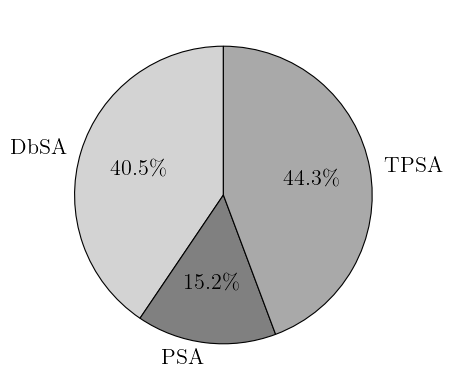

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 🎨 LaTeX-Stil aktivieren
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "figure.titlesize": 16
})

# 📂 CSV einlesen
df = pd.read_csv("Metrics_averaged.csv")

# 📊 Durchschnittlicher PF-Share je Algorithmus
pf_share_avg = df.groupby("Algorithm")["PF-Share"].mean()

# 📋 Labels mit Prozentangabe
labels = [f"{alg}" for alg in pf_share_avg.index]
colors = ["lightgray", "gray", "darkgray"]

# 🥧 Kreisdiagramm mit schwarzem Rand
fig, ax = plt.subplots(figsize=(4.8, 4.2))
wedges, texts, autotexts = ax.pie(
    pf_share_avg,
    labels=labels,
    colors=colors,
    startangle=90,
    autopct="%1.1f\\%%",
    textprops={"fontsize": 16},
    wedgeprops={"edgecolor": "black", "linewidth": 0.8}  # 🔲 schwarzer Rand
)

# 🖼️ Titel
#ax.set_title("Average PF-Share per Algorithm", fontsize=12)

# 💾 Optional speichern
#plt.savefig("pf_share_piechart_blackedge.pdf", bbox_inches="tight", dpi=300)

plt.tight_layout()
plt.show()